<a href="https://colab.research.google.com/github/xcl-esc/Analise_Goodreads/blob/main/C%C3%B3digos/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/projeto_novo/Códigos/

/content/drive/MyDrive/projeto_novo/Códigos


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/projeto_novo/Dados/Dados_limpos/dados_limpos.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11121 entries, 0 to 11120
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11121 non-null  int64  
 1   title               11121 non-null  object 
 2   authors             11121 non-null  object 
 3   average_rating      11121 non-null  float64
 4   isbn                11121 non-null  object 
 5   isbn13              11121 non-null  int64  
 6   language_code       11121 non-null  object 
 7   num_pages           11121 non-null  int64  
 8   ratings_count       11121 non-null  int64  
 9   text_reviews_count  11121 non-null  int64  
 10  publication_date    11121 non-null  object 
 11  publisher           11121 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


In [ ]:
df_relevancia = df[df['ratings_count'] >= 100].copy()

features = ['average_rating', 'ratings_count', 'text_reviews_count']
X = df_relevancia[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_init=10, random_state=42)
df_relevancia['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=4, random_state=42)
df_relevancia['cluster_gmm'] = gmm.fit_predict(X_scaled)

Davies-Bouldin: 0.4891
Davies-Bouldin: 0.7075
Davies-Bouldin: 0.6776
Davies-Bouldin: 0.6840
Davies-Bouldin: 0.7253
Davies-Bouldin: 0.6506
Davies-Bouldin: 0.6527


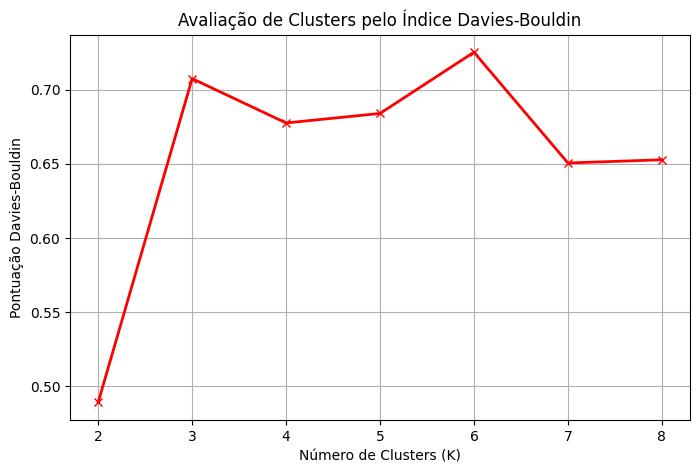

In [ ]:
def avaliacao_cluster(data_scaled):
  db_scores = []
  K_range = range(2, 9)

  for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(data_scaled)
    score = davies_bouldin_score(data_scaled, labels)
    db_scores.append(score)
    print(f'Davies-Bouldin: {score:.4f}')

  plt.figure(figsize=(8, 5))
  plt.plot(K_range, db_scores, 'rx-', linewidth=2)
  plt.xlabel('Número de Clusters (K)')
  plt.ylabel('Pontuação Davies-Bouldin')
  plt.title('Avaliação de Clusters pelo Índice Davies-Bouldin')
  plt.grid(True)
  plt.show()

avaliacao_cluster(X_scaled)

In [ ]:
k_ideal = 2

kmeans_final = KMeans(n_clusters=k_ideal, n_init=10, random_state=42)
df_relevancia['cluster_final'] = kmeans_final.fit_predict(X_scaled)

perfil_clusters = df_relevancia.groupby('cluster_final')[features].mean()
print("\n--- Perfil Médio de Cada Cluster ---")
print(perfil_clusters)


--- Perfil Médio de Cada Cluster ---
               average_rating  ratings_count  text_reviews_count
cluster_final                                                   
0                    3.954147   1.663737e+04          572.370202
1                    4.068947   1.587764e+06        32419.921053


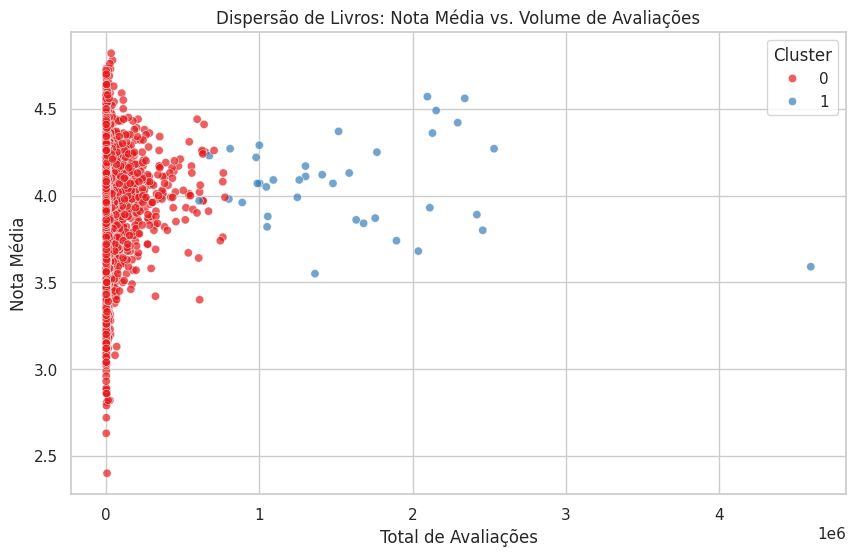

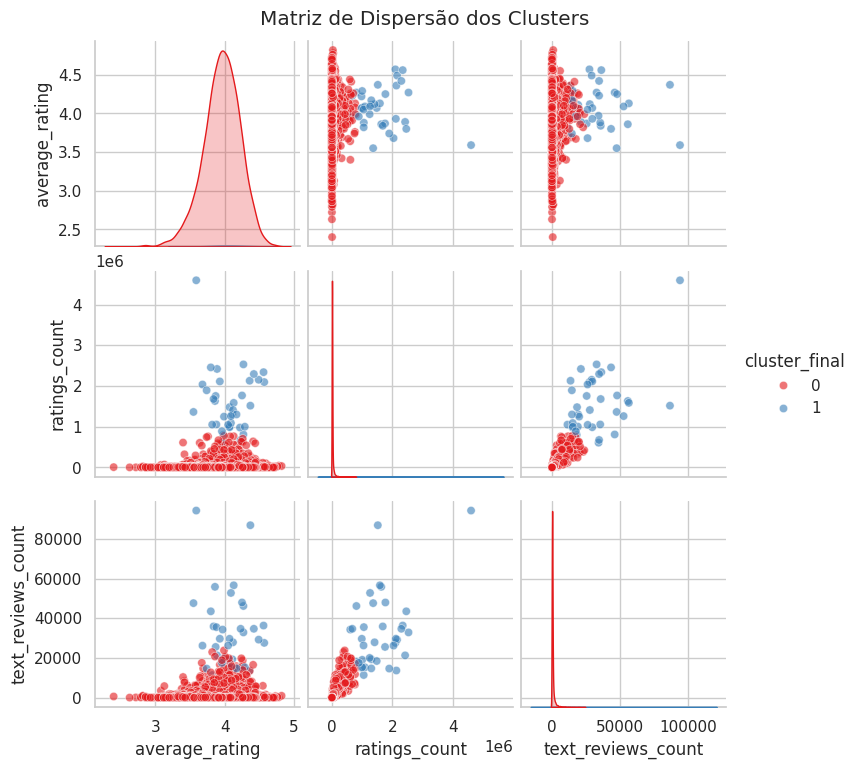

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_relevancia,
    x='ratings_count',
    y='average_rating',
    hue='cluster_final',
    palette='Set1',
    alpha=0.7
)
plt.title('Dispersão de Livros: Nota Média vs. Volume de Avaliações')
plt.xlabel('Total de Avaliações')
plt.ylabel('Nota Média')
plt.legend(title='Cluster')
plt.show()

df_pairplot = df_relevancia[features + ['cluster_final']]

sns.pairplot(
    df_pairplot,
    hue='cluster_final',
    palette='Set1',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Matriz de Dispersão dos Clusters', y=1.02)
plt.show()

In [ ]:
autor_medias = df_relevancia.groupby('authors')['ratings_count'].mean().to_dict()
editora_medias = df_relevancia.groupby('publisher')['ratings_count'].mean().to_dict()

df_tree = df_relevancia.copy()
df_tree['author_weight'] = df_tree['authors'].map(autor_medias)
df_tree['publisher_weight'] = df_tree['publisher'].map(editora_medias)

X_tree = df_tree[['author_weight', 'publisher_weight']]
y_tree = df_tree['cluster_final']

X_train, X_test, y_train, y_test = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42, stratify=y_tree
)

modelo_arvore = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
modelo_arvore.fit(X_train, y_train)

previsoes = modelo_arvore.predict(X_test)

print("\n--- Desempenho da Árvore de Decisão ---")
print(classification_report(y_test, previsoes, target_names=['Comum (Cluster 0)', 'Fenômeno (Cluster 1)']))


--- Desempenho da Árvore de Decisão ---
                      precision    recall  f1-score   support

   Comum (Cluster 0)       1.00      0.96      0.98      1673
Fenômeno (Cluster 1)       0.10      0.88      0.18         8

            accuracy                           0.96      1681
           macro avg       0.55      0.92      0.58      1681
        weighted avg       1.00      0.96      0.98      1681



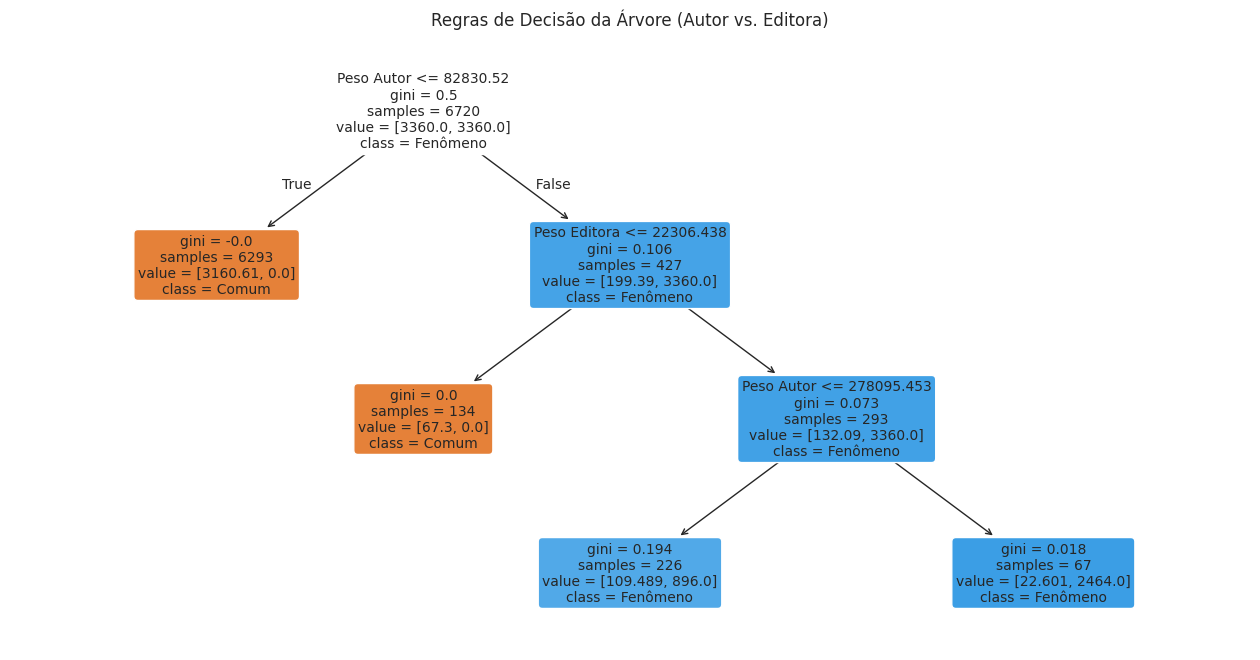

In [ ]:
plt.figure(figsize=(16, 8))
plot_tree(
    modelo_arvore,
    feature_names=['Peso Autor', 'Peso Editora'],
    class_names=['Comum', 'Fenômeno'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Regras de Decisão da Árvore (Autor vs. Editora)")
plt.show()